# 温和放量 Q3/Q4 正斜率因子分析

本 Notebook 用于分析一个离散持仓型成交额斜率因子：

```text
计算成交额斜率 slope = LINEARREG_SLOPE(total_turnover, window)
每天按 slope 做横截面 5 分位分组
买入 Q3 / Q4，卖出其他股票
并且要求 Q3 / Q4 中的 slope 必须大于 0
```

也就是说，最终信号不是简单的连续型 slope，而是：

```text
signal = 1  当股票属于 Q3 或 Q4，且 slope > 0
signal = 0  其他情况
```

这个设定试图捕捉“温和放量但不过热”的股票，避开最高放量组 Q5。

## 0. 环境准备

这个 Notebook 不强制依赖 Alphalens。因为该因子是 0/1 离散持仓信号，用标准 Alphalens 分位数 tear sheet 不一定最自然。

因此这里会重点做：

1. 持仓组 vs 非持仓组前向收益。
2. 持仓组 vs 全市场等权收益。
3. 信号 IC / Rank IC。
4. 持仓数量、覆盖率和换手率。
5. 按年份观察稳定性。

如果环境中装了 `alphalens`，也会额外构造 `factor_data` 供进一步 tear sheet 使用。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore")

try:
    import alphalens as al
    HAS_ALPHALENS = True
    print("Alphalens 可用。")
except Exception as exc:
    HAS_ALPHALENS = False
    print(f"Alphalens 不可用，将使用 Pandas 分析。原因：{type(exc).__name__}: {exc}")

Alphalens 可用。


## 1. 参数配置

日期需要和 `prepare_cn_stock_data_rq.py` 生成的缓存文件名一致。

In [ ]:
DATA_DIR = Path("data_rq")
OUTPUT_DIR = Path("results/alphalens_moderate_q34_positive")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = "2020-01-01"
END_DATE = "2026-04-29"

# 成交额斜率窗口
FACTOR_WINDOW = 20

# 横截面分成 5 组，买 Q3/Q4
QUANTILES = 5
BUY_QUANTILES = [3, 4]

# 前向收益观察窗口
FORWARD_PERIODS = (1, 5, 10, 20)

# 快速试跑时可限制股票数量；正式分析设为 None
MAX_ASSETS = None

print("输出目录：", OUTPUT_DIR.resolve())

## 2. 读取缓存数据

需要读取：

- `close`：用于计算未来收益。
- `total_turnover`：用于计算成交额斜率。

In [ ]:
def matrix_path(data_dir: Path, field: str, start_date: str, end_date: str) -> Path:
    """Return the required parquet cache path for a date x stock matrix."""
    stem = f"cn_stock_{field}_{start_date.replace('-', '')}_{end_date.replace('-', '')}"
    parquet_path = data_dir / f"{stem}.parquet"
    if parquet_path.exists():
        return parquet_path
    raise FileNotFoundError(f"Missing {field} parquet cache: {parquet_path}")


def read_matrix(data_dir: Path, field: str, start_date: str, end_date: str) -> pd.DataFrame:
    """Read a parquet date x stock matrix and normalize index/column order."""
    path = matrix_path(data_dir, field, start_date, end_date)
    print(f"Reading {field}: {path}")
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df.sort_index().sort_index(axis=1)






close = read_matrix(DATA_DIR, "close", START_DATE, END_DATE)
turnover = read_matrix(DATA_DIR, "total_turnover", START_DATE, END_DATE)

common_assets = close.columns.intersection(turnover.columns)
if MAX_ASSETS is not None:
    common_assets = common_assets[:MAX_ASSETS]

close = close[common_assets]
turnover = turnover[common_assets]

print("close shape:", close.shape)
print("turnover shape:", turnover.shape)
display(close.head())

## 3. 计算成交额斜率 slope

这里用 Pandas 实现滚动线性回归斜率，逻辑与策略脚本一致。

In [4]:
def calc_linearreg_slope(values: pd.DataFrame, window: int) -> pd.DataFrame:
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    denominator = ((x - x_mean) ** 2).sum()

    def slope_one_window(y):
        if np.isnan(y).any():
            return np.nan
        y_mean = y.mean()
        return ((x - x_mean) * (y - y_mean)).sum() / denominator

    return values.rolling(window, min_periods=window).apply(slope_one_window, raw=True)


slope = calc_linearreg_slope(turnover, FACTOR_WINDOW)
slope = slope.replace([np.inf, -np.inf], np.nan)

print("slope shape:", slope.shape)
display(slope.tail())

slope shape: (1530, 5114)


,000001.XSHE,000002.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,000025.XSHE,000026.XSHE,000027.XSHE,000028.XSHE,000029.XSHE,...,688758.XSHG,688766.XSHG,688767.XSHG,688768.XSHG,688772.XSHG,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-22,-1.411884e+07,-8.690787e+05,2.386899e+05,682955.268722,-2.822390e+07,5.728833e+05,1.285091e+06,-691017.266744,-2.096913e+06,-1.228512e+07,1.942180e+06,685285.379195,-1.983233e+06,-1.716242e+07,-2.506493e+07,-6.234501e+04,2.885310e+07,-5.520150e+07,-3.256706e+05,-234422.265759,...,4.478578e+06,6.228613e+06,2.588693e+06,-226599.960150,2.605663e+07,-181135.943609,4.152642e+07,3.270107e+07,7.527175e+05,1.019902e+06,-3.598178e+06,362432.009023,-1.919857e+06,-6.981510e+06,7.596875e+06,-8.105692e+06,1.571719e+07,-2.174447e+06,1.278339e+08,-9.145346e+06
2026-04-23,-1.562064e+07,-7.452700e+05,2.760737e+06,393444.790474,-3.795516e+07,1.490705e+06,1.349854e+06,-919483.853985,-1.379450e+06,-1.171277e+07,1.361111e+06,928402.316669,-1.817260e+05,-1.179635e+07,-6.011057e+06,8.414128e+04,3.175150e+07,-4.734546e+07,-1.810127e+06,492863.015090,...,4.339268e+06,1.496162e+07,2.403457e+06,-28787.592481,2.472333e+07,73906.403008,4.060291e+07,3.993003e+07,1.927272e+06,1.310773e+06,-2.776310e+06,491004.825564,-3.458647e+06,-6.082780e+06,9.000622e+06,-1.313559e+07,2.142885e+07,-2.267069e+06,1.290833e+08,-4.783923e+06
2026-04-24,-1.643291e+07,-1.795827e+06,6.098429e+06,-256772.990256,-4.806319e+07,2.112718e+06,1.097468e+05,-992436.499173,-1.316472e+06,-1.113051e+07,-5.694623e+05,852832.964624,1.493144e+06,-9.289834e+06,1.820809e+06,1.075522e+05,3.124198e+07,-3.773102e+07,-4.261694e+06,176653.652083,...,2.612357e+06,1.283764e+07,2.372996e+06,-249904.184962,2.224767e+07,-70588.391729,3.674367e+07,4.136324e+07,5.032015e+06,1.101727e+06,-7.285325e+05,-86740.748872,-5.381022e+06,-5.255292e+06,1.071162e+07,-1.801222e+07,1.961118e+07,-1.890054e+06,2.008094e+08,-1.937943e+06
2026-04-27,3.062061e+07,-4.725102e+06,6.535197e+06,-700149.705308,-5.927933e+07,2.847001e+06,6.068236e+05,-981268.773789,-1.489041e+06,-8.843478e+06,-1.006973e+06,837819.116489,-2.715280e+05,-6.837869e+06,8.762683e+06,7.516889e+05,2.986008e+07,-1.945623e+07,-6.367474e+06,98379.009865,...,7.013191e+05,4.435392e+06,2.385534e+06,-123701.943609,1.893504e+07,-688934.194737,5.544215e+07,3.892184e+07,6.411877e+06,7.569105e+05,-6.167277e+05,283529.001504,-6.763090e+06,-4.310139e+06,1.092482e+07,-1.541179e+07,1.568886e+07,-1.248188e+06,2.750681e+08,-2.916688e+06
2026-04-28,4.058334e+07,-5.220281e+06,4.436267e+06,-50368.937955,-6.545763e+07,3.126266e+06,-4.185577e+05,-607885.872797,1.870476e+06,-7.144799e+06,-2.352285e+06,923403.574594,1.652318e+06,-5.713199e+06,5.473897e+06,1.773275e+06,2.592768e+07,-7.680631e+06,-7.454010e+06,578696.364714,...,-9.457057e+05,7.399984e+06,2.032124e+06,881794.366917,1.669867e+07,-904163.330075,6.184257e+07,3.418312e+07,9.189574e+06,2.183905e+06,1.312265e+06,432966.384211,-8.106908e+06,-3.115594e+06,1.272237e+07,-1.489403e+07,1.348182e+07,-7.633310e+05,2.850037e+08,-1.629152e+06


## 4. 构造 Q3/Q4 且 slope > 0 的持仓信号

每天对所有股票的 slope 做横截面分位数：

```text
Q1 = 斜率最低组
Q5 = 斜率最高组
```

本策略只买：

```text
quantile in [3, 4] 且 slope > 0
```

这样可以避开 Q5 极端放量组，同时要求成交额趋势仍然为正。

In [5]:
def assign_daily_quantiles(factor_row: pd.Series, quantiles: int) -> pd.Series:
    valid = factor_row.dropna()
    out = pd.Series(np.nan, index=factor_row.index)
    if len(valid) < quantiles * 10:
        return out
    try:
        out.loc[valid.index] = pd.qcut(valid, quantiles, labels=False, duplicates="drop").astype(float) + 1
    except ValueError:
        pass
    return out


quantile = slope.apply(lambda row: assign_daily_quantiles(row, QUANTILES), axis=1)
signal = quantile.isin(BUY_QUANTILES) & (slope > 0)
signal = signal.fillna(False)

# 作为因子分析输入，signal_factor 用 1/0 表示是否进入持仓组
signal_factor = signal.astype(float)

coverage = signal.sum(axis=1)
coverage_ratio = signal.mean(axis=1)

print("平均持仓股票数：", coverage.mean())
print("平均覆盖比例：", coverage_ratio.mean())
display(pd.DataFrame({"selected_count": coverage, "coverage_ratio": coverage_ratio}).describe())

平均持仓股票数： 1112.3359477124184
平均覆盖比例： 0.2175080069832652


,selected_count,coverage_ratio
count,1530.000000,1530.000000
mean,1112.335948,0.217508
std,566.162926,0.110708
min,0.000000,0.000000
25%,707.000000,0.138248
50%,1120.000000,0.219007
75%,1537.750000,0.300694
max,2045.000000,0.399883


## 5. 计算未来收益

对每个观察窗口 `p`：

```text
forward_return_p = close[t+p] / close[t] - 1
```

注意：这是因子分析口径，不是交易回测口径；它用于观察信号出现后未来收益是否更好。

In [6]:
forward_returns = {p: close.pct_change(p).shift(-p) for p in FORWARD_PERIODS}

for p, fwd in forward_returns.items():
    print(p, fwd.shape, fwd.notna().sum().sum())

1 (1530, 5114) 7052615
5 (1530, 5114) 7032159
10 (1530, 5114) 7006589
20 (1530, 5114) 6955449


## 6. 持仓组 vs 非持仓组 / 全市场

这里直接回答最重要的问题：

```text
Q3/Q4 且 slope > 0 的股票，未来收益是否高于其他股票？
Q3/Q4 且 slope > 0 的股票，未来收益是否高于全市场平均？
```

In [7]:
def calc_group_forward_summary(signal: pd.DataFrame, fwd_ret: pd.DataFrame):
    rows = []
    daily_spread = []
    for dt in signal.index.intersection(fwd_ret.index):
        sig = signal.loc[dt]
        ret = fwd_ret.loc[dt]
        df = pd.DataFrame({"signal": sig, "ret": ret}).dropna()
        if df.empty or df["signal"].sum() == 0:
            continue
        selected_ret = df.loc[df["signal"], "ret"].mean()
        unselected_ret = df.loc[~df["signal"], "ret"].mean()
        market_ret = df["ret"].mean()
        spread_vs_unselected = selected_ret - unselected_ret
        spread_vs_market = selected_ret - market_ret
        rows.append({
            "date": dt,
            "selected_ret": selected_ret,
            "unselected_ret": unselected_ret,
            "market_ret": market_ret,
            "spread_vs_unselected": spread_vs_unselected,
            "spread_vs_market": spread_vs_market,
            "selected_count": int(df["signal"].sum()),
            "universe_count": len(df),
        })
        daily_spread.append((dt, spread_vs_unselected))
    out = pd.DataFrame(rows).set_index("date")
    return out, out["spread_vs_unselected"]


group_results = {}
summary_rows = []

for p, fwd in forward_returns.items():
    daily, spread = calc_group_forward_summary(signal, fwd)
    group_results[p] = daily
    summary_rows.append({
        "period": p,
        "selected_ret_mean": daily["selected_ret"].mean(),
        "unselected_ret_mean": daily["unselected_ret"].mean(),
        "market_ret_mean": daily["market_ret"].mean(),
        "spread_vs_unselected_mean": daily["spread_vs_unselected"].mean(),
        "spread_vs_unselected_t": daily["spread_vs_unselected"].mean() / daily["spread_vs_unselected"].std() * np.sqrt(len(daily)),
        "spread_vs_unselected_pos_ratio": (daily["spread_vs_unselected"] > 0).mean(),
        "spread_vs_market_mean": daily["spread_vs_market"].mean(),
        "spread_vs_market_t": daily["spread_vs_market"].mean() / daily["spread_vs_market"].std() * np.sqrt(len(daily)),
        "spread_vs_market_pos_ratio": (daily["spread_vs_market"] > 0).mean(),
        "avg_selected_count": daily["selected_count"].mean(),
        "days": len(daily),
    })

group_summary = pd.DataFrame(summary_rows).set_index("period")
display(group_summary)
group_summary.to_csv(OUTPUT_DIR / f"q34_positive_group_summary_w{FACTOR_WINDOW}.csv", encoding="utf-8-sig")

,selected_ret_mean,unselected_ret_mean,market_ret_mean,spread_vs_unselected_mean,spread_vs_unselected_t,spread_vs_unselected_pos_ratio,spread_vs_market_mean,spread_vs_market_t,spread_vs_market_pos_ratio,avg_selected_count,days
period,,,,,,,,,,,
1,0.001011,0.000414,0.000571,0.000597,6.794751,0.580514,0.000440,6.322252,0.580514,1150.087280,1478
5,0.004703,0.002524,0.003070,0.002180,10.417098,0.628223,0.001634,9.464744,0.628223,1147.765265,1474
10,0.008990,0.005373,0.006269,0.003618,11.512858,0.663717,0.002721,10.289507,0.663717,1147.489449,1469
20,0.016313,0.010531,0.011924,0.005781,13.003068,0.677176,0.004388,11.809073,0.677176,1151.130226,1459


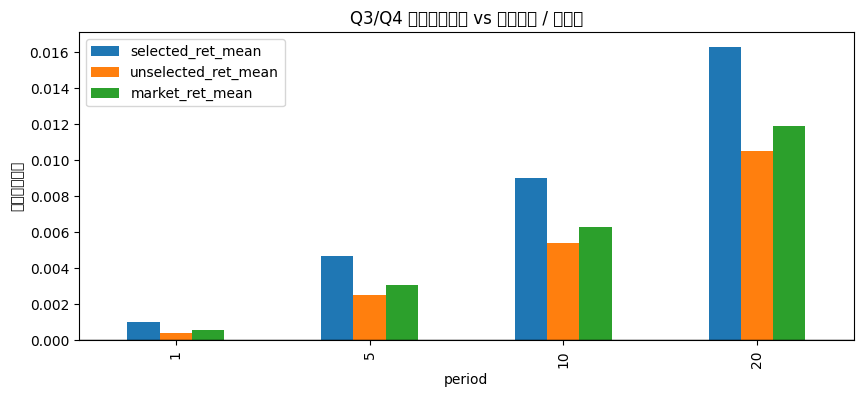

In [8]:
# 画出持仓组、非持仓组、全市场的平均未来收益对比
plot_df = group_summary[["selected_ret_mean", "unselected_ret_mean", "market_ret_mean"]]
plot_df.plot(kind="bar", figsize=(10, 4), title="Q3/Q4 正斜率持仓组 vs 非持仓组 / 全市场")
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("平均未来收益")
plt.show()

## 7. 信号 IC / Rank IC

因为 `signal_factor` 是 0/1 信号，这里的 IC 含义是：

```text
被选中股票是否比未选中股票未来收益更高
```

如果 IC 为正，说明选中组相对更强；如果为负，说明这个持仓规则反而选到了更弱的股票。

In [9]:
def rank_corr(a: pd.Series, b: pd.Series) -> float:
    return a.rank().corr(b.rank())


def calc_daily_signal_ic(signal_factor: pd.DataFrame, fwd_ret: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for dt in signal_factor.index.intersection(fwd_ret.index):
        df = pd.DataFrame({"factor": signal_factor.loc[dt], "ret": fwd_ret.loc[dt]}).dropna()
        if len(df) < 30 or df["factor"].nunique() < 2:
            continue
        rows.append({
            "date": dt,
            "ic": df["factor"].corr(df["ret"]),
            "rank_ic": rank_corr(df["factor"], df["ret"]),
            "count": len(df),
        })
    return pd.DataFrame(rows).set_index("date")


ic_results = {}
ic_summary_rows = []

for p, fwd in forward_returns.items():
    ic_df = calc_daily_signal_ic(signal_factor, fwd)
    ic_results[p] = ic_df
    ic_summary_rows.append({
        "period": p,
        "ic_mean": ic_df["ic"].mean(),
        "ic_t": ic_df["ic"].mean() / ic_df["ic"].std() * np.sqrt(len(ic_df)),
        "rank_ic_mean": ic_df["rank_ic"].mean(),
        "rank_ic_t": ic_df["rank_ic"].mean() / ic_df["rank_ic"].std() * np.sqrt(len(ic_df)),
        "rank_ic_pos_ratio": (ic_df["rank_ic"] > 0).mean(),
        "days": len(ic_df),
    })

ic_summary = pd.DataFrame(ic_summary_rows).set_index("period")
display(ic_summary)
ic_summary.to_csv(OUTPUT_DIR / f"q34_positive_ic_summary_w{FACTOR_WINDOW}.csv", encoding="utf-8-sig")

,ic_mean,ic_t,rank_ic_mean,rank_ic_t,rank_ic_pos_ratio,days
period,,,,,,
1,0.009383,7.624755,0.011778,7.563799,0.566982,1478
5,0.015676,13.471216,0.023178,15.682984,0.658073,1474
10,0.018509,15.663452,0.028287,19.064436,0.695031,1469
20,0.020757,16.926653,0.032588,21.422639,0.721042,1459


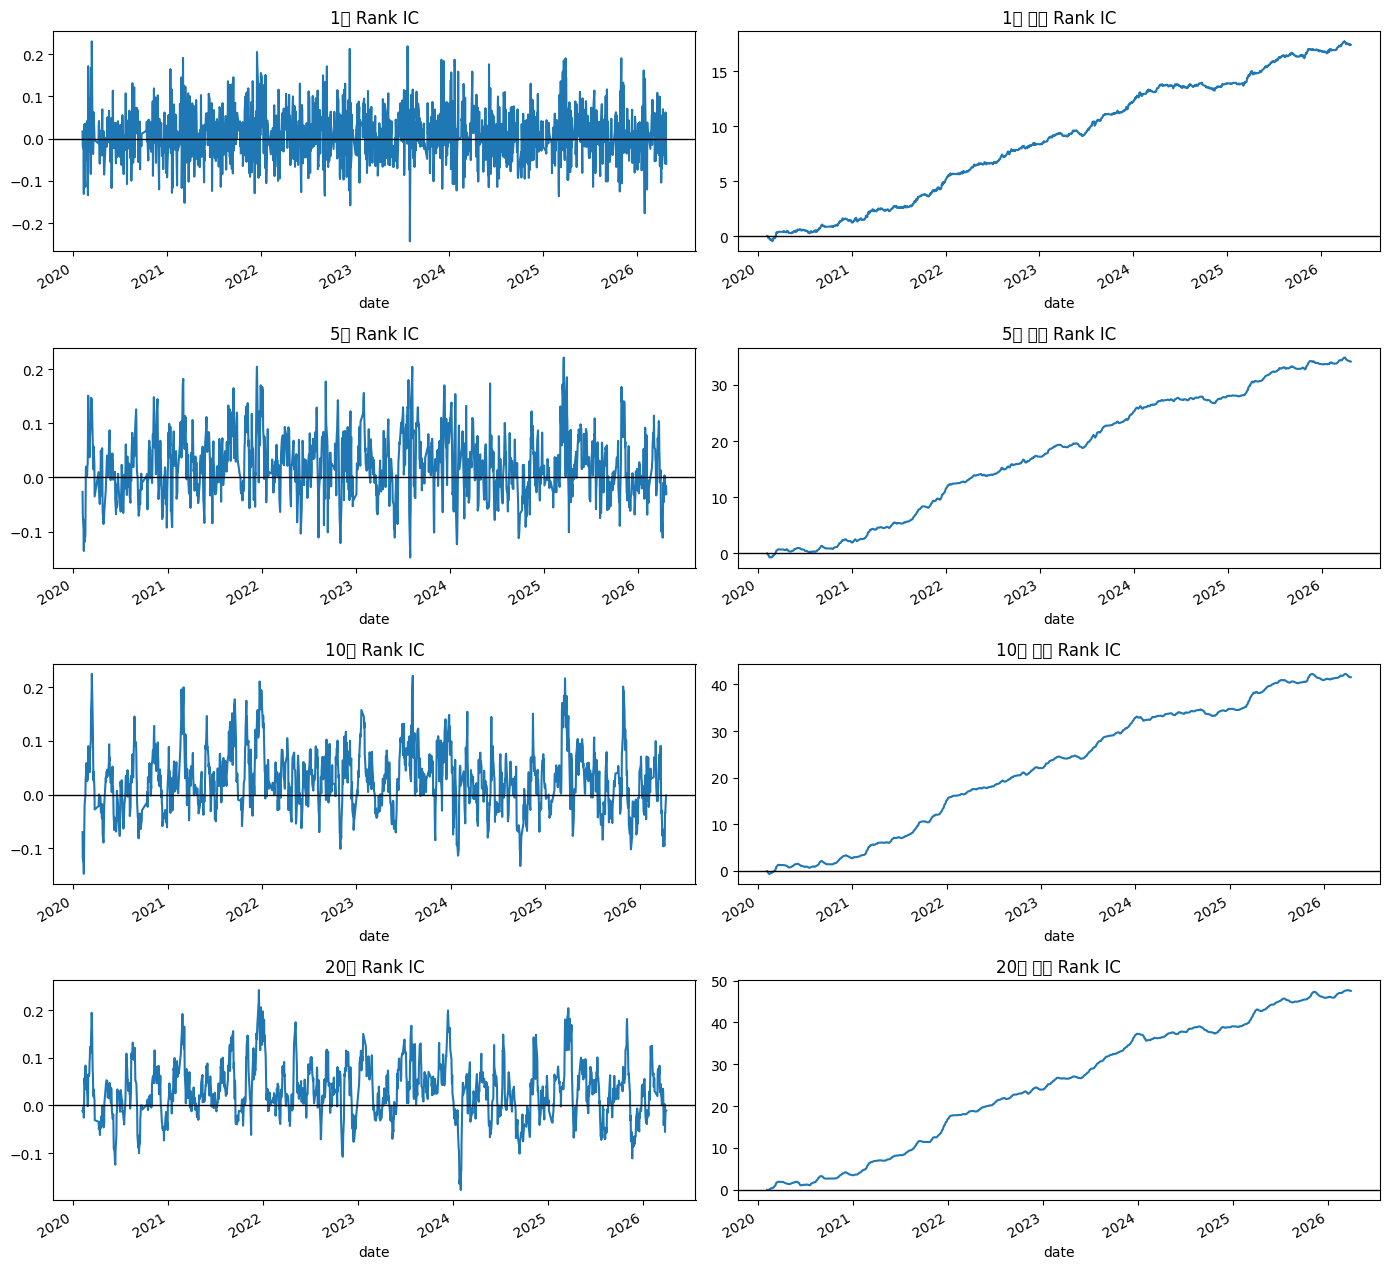

In [10]:
fig, axes = plt.subplots(len(FORWARD_PERIODS), 2, figsize=(14, 3.2 * len(FORWARD_PERIODS)))
if len(FORWARD_PERIODS) == 1:
    axes = np.array([axes])

for row, p in enumerate(FORWARD_PERIODS):
    ic_df = ic_results[p]
    ic_df["rank_ic"].plot(ax=axes[row, 0], title=f"{p}日 Rank IC")
    ic_df["rank_ic"].cumsum().plot(ax=axes[row, 1], title=f"{p}日 累计 Rank IC")
    axes[row, 0].axhline(0, color="black", linewidth=1)
    axes[row, 1].axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

## 8. 年度稳定性

这一节观察信号是否只在某些年份有效。

In [11]:
yearly_rows = []

for p, daily in group_results.items():
    temp = daily.copy()
    temp["year"] = temp.index.year
    for year, gy in temp.groupby("year"):
        yearly_rows.append({
            "period": p,
            "year": year,
            "selected_ret_mean": gy["selected_ret"].mean(),
            "spread_vs_unselected_mean": gy["spread_vs_unselected"].mean(),
            "spread_vs_unselected_t": gy["spread_vs_unselected"].mean() / gy["spread_vs_unselected"].std() * np.sqrt(len(gy)),
            "spread_vs_market_mean": gy["spread_vs_market"].mean(),
            "days": len(gy),
        })

yearly_summary = pd.DataFrame(yearly_rows)
display(yearly_summary.pivot(index="year", columns="period", values="spread_vs_unselected_mean"))
yearly_summary.to_csv(OUTPUT_DIR / f"q34_positive_yearly_summary_w{FACTOR_WINDOW}.csv", index=False, encoding="utf-8-sig")

period,1,5,10,20
year,,,,
2020,0.000663,0.001181,0.001657,0.003335
2021,0.000727,0.003447,0.007034,0.011555
2022,0.000858,0.003260,0.005397,0.007284
2023,0.000460,0.002508,0.004652,0.007907
2024,0.000450,0.001088,0.000754,-0.000085
2025,0.000549,0.002053,0.002891,0.004506
2026,0.000240,0.000235,0.000253,0.005240


## 9. 覆盖率和换手

这里分析每天选中的股票数量，以及持仓组换手。

换手定义：

```text
turnover = 1 - 当天持仓集合与前一天持仓集合的重合比例
```

In [12]:
def calc_set_turnover(signal: pd.DataFrame) -> pd.Series:
    previous = None
    rows = []
    for dt in signal.index:
        current = set(signal.columns[signal.loc[dt].fillna(False)])
        if previous is not None and previous:
            rows.append((dt, 1 - len(current.intersection(previous)) / len(previous)))
        previous = current
    return pd.Series(dict(rows), name="set_turnover").sort_index()


set_turnover = calc_set_turnover(signal)
diagnostics = pd.DataFrame({
    "selected_count": coverage,
    "coverage_ratio": coverage_ratio,
    "set_turnover": set_turnover,
})

display(diagnostics.describe())
diagnostics.to_csv(OUTPUT_DIR / f"q34_positive_diagnostics_w{FACTOR_WINDOW}.csv", encoding="utf-8-sig")

,selected_count,coverage_ratio,set_turnover
count,1530.000000,1530.000000,1478.000000
mean,1112.335948,0.217508,0.253970
std,566.162926,0.110708,0.144258
min,0.000000,0.000000,0.048986
25%,707.000000,0.138248,0.157467
50%,1120.000000,0.219007,0.211815
75%,1537.750000,0.300694,0.298455
max,2045.000000,0.399883,1.000000


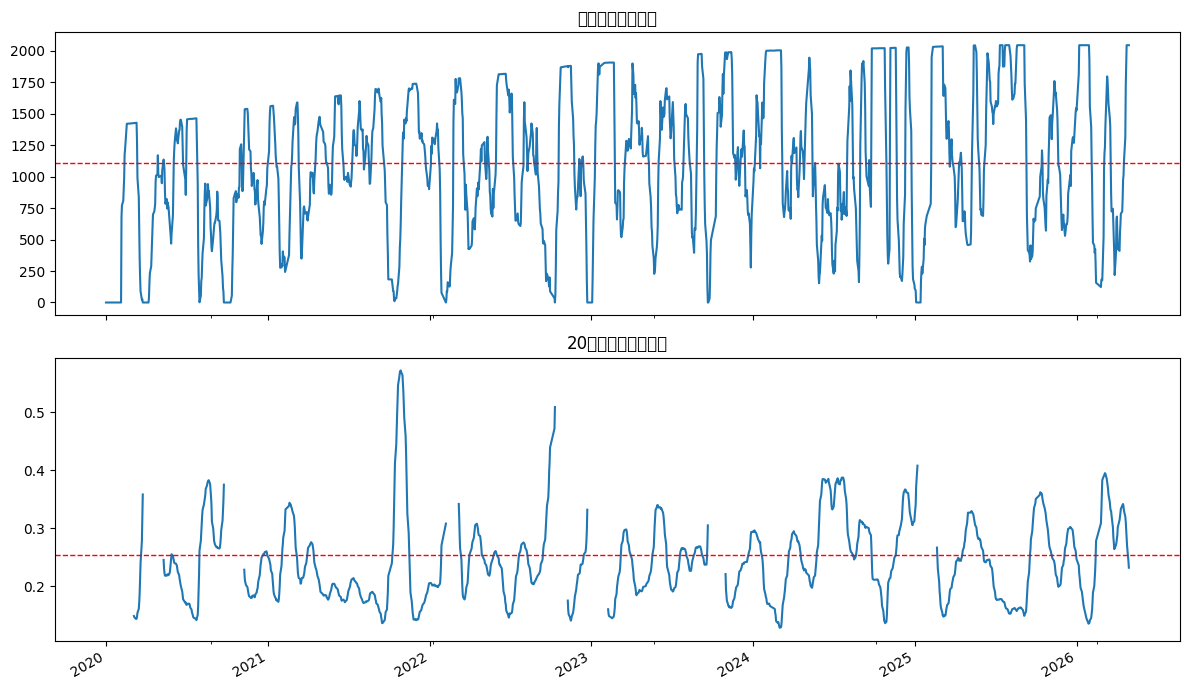

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

diagnostics["selected_count"].plot(ax=axes[0], title="每日选中股票数量")
diagnostics["set_turnover"].rolling(20).mean().plot(ax=axes[1], title="20日平均集合换手率")

axes[0].axhline(diagnostics["selected_count"].mean(), color="red", linestyle="--", linewidth=1)
axes[1].axhline(diagnostics["set_turnover"].mean(), color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

## 10. 可选：构造 Alphalens factor_data

如果环境中安装了 Alphalens，可以把 `signal_factor` 当成 0/1 因子传入。

注意：因为因子只有两个取值，标准的 5 分位 tear sheet 不适合它。这里更适合看 IC 和二元分组收益。

In [15]:
if HAS_ALPHALENS:
    factor_series = signal_factor.stack(dropna=True)
    factor_series.index = factor_series.index.set_names(["date", "asset"])
    factor_series.name = "q34_positive_signal"

    try:
        factor_data = al.utils.get_clean_factor_and_forward_returns(
            factor=factor_series,
            prices=close,
            periods=FORWARD_PERIODS,
            quantiles=None,
            bins=2,
            max_loss=0.5,
        )
        display(factor_data.head())
        factor_data.to_csv(
            OUTPUT_DIR / f"alphalens_factor_data_q34_positive_w{FACTOR_WINDOW}.csv",
            encoding="utf-8-sig"
        )
    except Exception as exc:
        print("Alphalens factor_data 构造失败，但前面的 Pandas 分析结果已经足够用于判断该信号。")
        print(f"失败原因：{type(exc).__name__}: {exc}")
else:
    print("Alphalens 不可用，跳过 factor_data 构造。")


Dropped 11.1% entries from factor data: 11.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 50.0%, not exceeded: OK!


1D        5D       10D       20D  factor  factor_quantile
date       asset                                                                       
2020-01-02 000001.XSHE  0.018376 -0.004742 -0.032009 -0.133373     0.0                1
           000002.XSHE -0.015663 -0.011057 -0.062346 -0.155405     0.0                1
           000006.XSHE  0.014815  0.012963 -0.001852 -0.162963     0.0                1
           000007.XSHE -0.004188 -0.011518 -0.024084 -0.207330     0.0                1
           000008.XSHE  0.010782  0.016173 -0.026954 -0.177898     0.0                1

## 11. 解读建议

重点看以下几个输出：

1. `q34_positive_group_summary`：持仓组是否跑赢非持仓组和全市场。
2. `q34_positive_ic_summary`：0/1 信号是否有正 IC。
3. `q34_positive_yearly_summary`：是否只是某些年份有效。
4. `q34_positive_diagnostics`：每天选中股票是否足够多，换手是否过高。

如果持仓组未来收益高于非持仓组，但策略回测仍然差，通常可能是：

- 执行价格和分析价格不一致。
- 换手和交易成本吃掉优势。
- 信号在 1D 有效但 10D/20D 无效，持有期设置不匹配。
- Q3/Q4 的横截面优势存在，但等权组合暴露了行业、市值或市场风格风险。

下一步可以进一步加入行业/市值中性化，或者把 Q3/Q4 信号改成周频调仓来降低换手。